Dataset shape: (5000, 784)
Reduced dimensions: 470


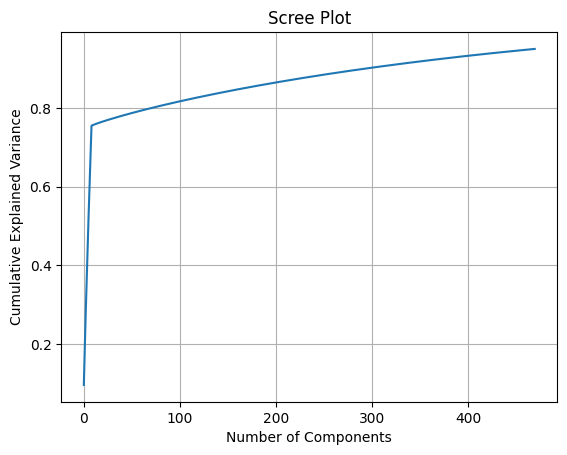

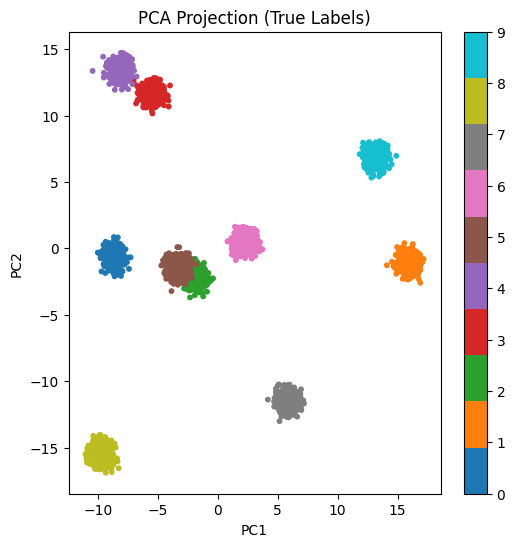

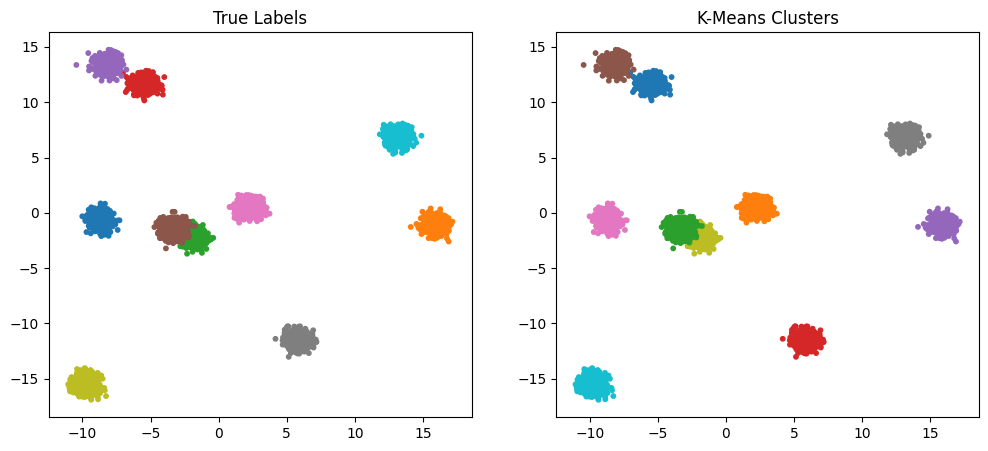

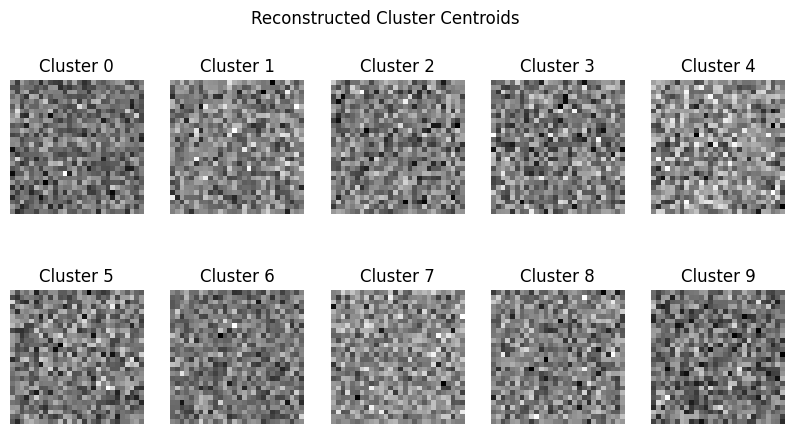

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

np.random.seed(42)

num_classes = 10
samples_per_class = 500
img_size = 28 * 28

X = []
y = []

base_centroids = np.random.randn(num_classes, img_size)

for i in range(num_classes):
    for _ in range(samples_per_class):
        sample = base_centroids[i] + np.random.normal(0, 0.5, img_size)
        X.append(sample)
        y.append(i)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Reduced dimensions:", X_pca.shape[1])

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='tab10',
    s=10
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (True Labels)")
plt.colorbar()
plt.show()

kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X_pca)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10)
plt.title("True Labels")

plt.subplot(1,2,2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='tab10', s=10)
plt.title("K-Means Clusters")
plt.show()

centroids = kmeans.cluster_centers_
centroids_original = pca.inverse_transform(centroids)
centroids_original = scaler.inverse_transform(centroids_original)

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    img = centroids_original[i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"Cluster {i}")
    plt.axis('off')

plt.suptitle("Reconstructed Cluster Centroids")
plt.show()